# Superstore Data Science Tutorial (School Style)

This notebook teaches data analysis and machine learning in very simple steps.

How to use this notebook:
1. Read markdown first.
2. Run one code cell at a time.
3. Check output before moving to the next cell.
4. Do the mini exercise in each section.

## Lesson 0: What we are trying to solve

We have Superstore order data.

We want to answer:
- Which category gives high sales?
- Which part of business gives low or negative profit?
- Does discount hurt profit?
- Can we predict profit using machine learning?

## Lesson 1: Import libraries

We load tools for data handling, charts, and ML.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


### Mini Exercise
Write 1 line: Why do we import pandas?

## Lesson 2: Load the dataset

This code tries common file paths and loads the CSV.

In [3]:
from pathlib import Path

possible_paths = [
    Path('SuperStoreOrders_SuperStoreOrders.csv'),
    Path('../SuperStoreOrders_SuperStoreOrders.csv'),
    Path('data/raw/SuperStoreOrders_SuperStoreOrders.csv')
]

file_path = None
for p in possible_paths:
    if p.exists():
        file_path = p
        break

if file_path is None:
    raise FileNotFoundError('CSV file not found. Please update possible_paths.')

df = pd.read_csv(file_path)
print('Loaded from:', file_path)
print('Shape:', df.shape)
df.head()

Loaded from: ..\SuperStoreOrders_SuperStoreOrders.csv
Shape: (1048575, 32)


,order_id,order_date,order_day,order_month,order_year,ship_date,ship_day,ship_month,ship_year,order_date_vs_ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,S_no,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,AG-2011-2040,2011-01-01,1,1,2011,2011-06-01,1,6,2011,151,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0,NaN,Total_Orders,51290
1,IN-2011-47883,2011-01-01,1,1,2011,2011-08-01,1,8,2011,212,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0,NaN,Total_Sales,"$12,642,905.00"
2,HU-2011-1220,2011-01-01,1,1,2011,2011-05-01,1,5,2011,120,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4.0,0.0,29.640,8.17,High,2011.0,3.0,NaN,Avg. Sales,$246.50
3,IT-2011-3647632,2011-01-01,1,1,2011,2011-05-01,1,5,2011,120,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3.0,0.5,-26.055,4.82,High,2011.0,4.0,NaN,Total_Profit,"$1,469,034.82"
4,IN-2011-47883,2011-01-01,1,1,2011,2011-08-01,1,8,2011,212,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0,NaN,Avg. Profit,$28.64


### Mini Exercise
How many rows and columns are in your data?

## Lesson 3: Understand the data

We check columns, types, missing values, and duplicates.

In [4]:
print('Columns:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.to_frame('dtype').T)

print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False).to_frame('missing_count').head(20))

print('Duplicate rows:', df.duplicated().sum())

Columns:
['order_id', 'order_date', 'order_day', 'order_month', 'order_year', 'ship_date', 'ship_day', 'ship_month', 'ship_year', 'order_date_vs_ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'S_no', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31']

Data types:


,order_id,order_date,order_day,order_month,order_year,ship_date,ship_day,ship_month,ship_year,order_date_vs_ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,S_no,Unnamed: 29,Unnamed: 30,Unnamed: 31
dtype,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,object,float64,float64,float64,object,object



Missing values:


,missing_count
Unnamed: 29,1048575
Unnamed: 31,1048568
Unnamed: 30,1048568
order_date,997285
S_no,997285
year,997285
order_priority,997285
shipping_cost,997285
profit,997285
discount,997285


Duplicate rows: 997283


## Lesson 4: Clean the data

Data cleaning steps:
- Standardize column names
- Convert date columns to real dates
- Remove duplicate rows
- Create helper columns for analysis

In [17]:
df.columns = [c.strip().replace(' ', '_') for c in df.columns]

for c in df.columns:
    if 'date' in c.lower():
        df[c] = pd.to_datetime(df[c], errors='coerce')

df = df.drop_duplicates().copy()

# Create friendly aliases so the next lessons work with different CSV column styles.
alias_map = {
    'sales': 'Sales',
    'profit': 'Profit',
    'discount': 'Discount',
    'order_date': 'Order_Date',
    'ship_date': 'Ship_Date',
    'category': 'Category',
    'sub_category': 'Sub_Category',
    'segment': 'Segment',
    'region': 'Region',
    'state': 'State',
    'product_name': 'Product_Name',
    'customer_name': 'Customer_Name',
    'order_id': 'Order_ID',
    'customer_id': 'Customer_ID',
    'row_id': 'Row_ID'
}

for src, dst in alias_map.items():
    if src in df.columns and dst not in df.columns:
        df[dst] = df[src]

# Ensure key numeric columns are truly numeric.
for num_col in ['Sales', 'Profit', 'Discount']:
    if num_col in df.columns:
        df[num_col] = pd.to_numeric(df[num_col], errors='coerce')

if 'Order_Date' in df.columns:
    df['Order_Year'] = df['Order_Date'].dt.year
    df['Order_Month'] = df['Order_Date'].dt.month

if {'Sales', 'Profit'}.issubset(df.columns):
    df['Profit_Margin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], np.nan)

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (51292, 48)


,order_id,order_date,order_day,order_month,order_year,ship_date,ship_day,ship_month,ship_year,order_date_vs_ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,S_no,Unnamed:_29,Unnamed:_30,Unnamed:_31,Sales,Profit,Discount,Order_Date,Ship_Date,Category,Sub_Category,Segment,Region,State,Product_Name,Customer_Name,Order_ID,Order_Year,Order_Month,Profit_Margin
0,AG-2011-2040,2011-01-01,1,1,2011,2011-06-01,1,6,2011,NaT,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0,NaN,Total_Orders,51290,408.0,106.140,0.0,2011-01-01,2011-06-01,Office Supplies,Storage,Consumer,Africa,Constantine,"Tenex Lockers, Blue",Toby Braunhardt,AG-2011-2040,2011.0,1.0,0.260147
1,IN-2011-47883,2011-01-01,1,1,2011,2011-08-01,1,8,2011,NaT,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0,NaN,Total_Sales,"$12,642,905.00",120.0,36.036,0.1,2011-01-01,2011-08-01,Office Supplies,Supplies,Consumer,Oceania,New South Wales,"Acme Trimmer, High Speed",Joseph Holt,IN-2011-47883,2011.0,1.0,0.300300
2,HU-2011-1220,2011-01-01,1,1,2011,2011-05-01,1,5,2011,NaT,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4.0,0.0,29.640,8.17,High,2011.0,3.0,NaN,Avg. Sales,$246.50,66.0,29.640,0.0,2011-01-01,2011-05-01,Office Supplies,Storage,Consumer,EMEA,Budapest,"Tenex Box, Single Width",Annie Thurman,HU-2011-1220,2011.0,1.0,0.449091
3,IT-2011-3647632,2011-01-01,1,1,2011,2011-05-01,1,5,2011,NaT,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3.0,0.5,-26.055,4.82,High,2011.0,4.0,NaN,Total_Profit,"$1,469,034.82",45.0,-26.055,0.5,2011-01-01,2011-05-01,Office Supplies,Paper,Home Office,North,Stockholm,"Enermax Note Cards, Premium",Eugene Moren,IT-2011-3647632,2011.0,1.0,-0.579000
4,IN-2011-47883,2011-01-01,1,1,2011,2011-08-01,1,8,2011,NaT,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0,NaN,Avg. Profit,$28.64,114.0,37.770,0.1,2011-01-01,2011-08-01,Furniture,Furnishings,Consumer,Oceania,New South Wales,"Eldon Light Bulb, Duo Pack",Joseph Holt,IN-2011-47883,2011.0,1.0,0.331316


### Mini Exercise
Explain in one sentence: Why do we convert dates before trend analysis?

## Lesson 5: Basic statistics

This gives quick summary (mean, min, max, etc.) for numeric columns.

In [6]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.000
discount,51290.0,0.145278,0.214113,0.000,0.00,0.00,0.20,0.900
profit,51290.0,28.641740,174.424113,-6599.978,0.00,9.24,36.81,8399.976
shipping_cost,51290.0,26.375915,57.296804,0.000,2.61,7.79,24.45,933.570
year,51290.0,2012.777208,1.098931,2011.000,2012.00,2013.00,2014.00,2014.000
S_no,51290.0,25645.500000,14806.291990,1.000,12823.25,25645.50,38467.75,51290.000
Unnamed:_29,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Lesson 6: First charts (easy visual analysis)

We plot distributions for Sales, Profit, and Discount.

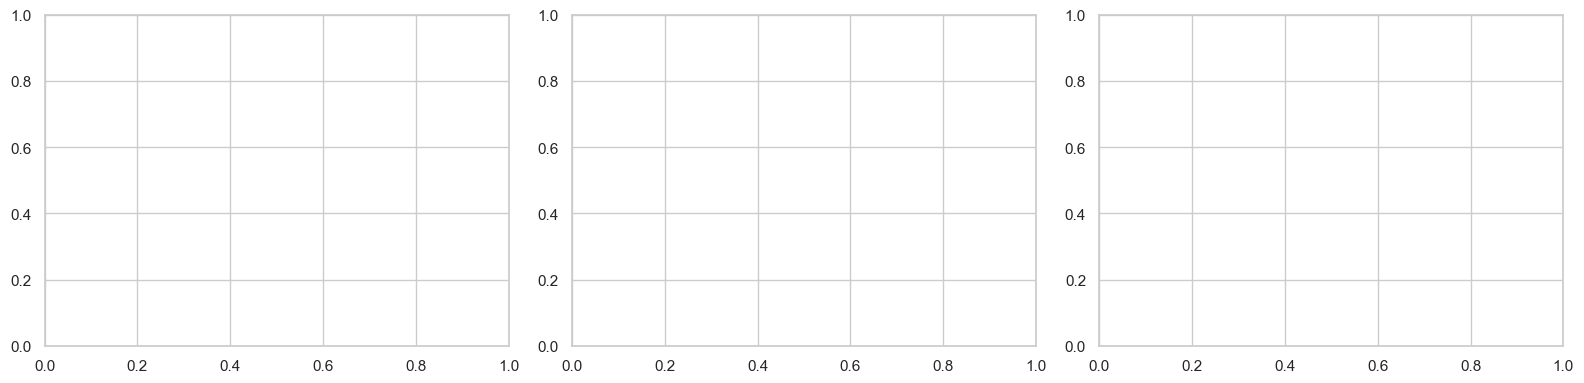

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if 'Sales' in df.columns:
    sns.histplot(df['Sales'], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('Sales Distribution')

if 'Profit' in df.columns:
    sns.histplot(df['Profit'], kde=True, ax=axes[1], color='seagreen')
    axes[1].set_title('Profit Distribution')

if 'Discount' in df.columns:
    sns.histplot(df['Discount'], kde=True, ax=axes[2], color='tomato')
    axes[2].set_title('Discount Distribution')

plt.tight_layout()
plt.show()

## Lesson 7: Business question analysis

Now we answer practical business questions.

In [9]:
if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    cat = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    print('Category summary:')
    display(cat)

if {'Region', 'Sales', 'Profit'}.issubset(df.columns):
    reg = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    print('Region summary:')
    display(reg)

if {'Sub_Category', 'Profit'}.issubset(df.columns):
    loss_sub = df.groupby('Sub_Category')['Profit'].sum().sort_values().head(10)
    print('Top 10 loss-making sub-categories:')
    display(loss_sub.to_frame('Total_Profit'))

In [10]:
if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.barplot(data=category_summary, x='Category', y='Sales', ax=axes[0], palette='Blues_d')
    axes[0].set_title('Sales by Category')

    sns.barplot(data=category_summary, x='Category', y='Profit', ax=axes[1], palette='Greens_d')
    axes[1].set_title('Profit by Category')

    plt.tight_layout()
    plt.show()

## Lesson 8: Discount vs Profit check

Important idea: higher discount can reduce profit.

In [11]:
if {'Discount', 'Profit'}.issubset(df.columns):
    sample_df = df.sample(min(4000, len(df)), random_state=42)
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=sample_df, x='Discount', y='Profit', alpha=0.5)
    plt.title('Discount vs Profit')
    plt.show()

### Mini Exercise
After looking at the chart, write your observation in 1-2 lines.

## Lesson 9: Time trend analysis

We check monthly sales and monthly profit.

In [12]:
if {'Order_Date', 'Sales', 'Profit'}.issubset(df.columns):
    monthly = (
        df.set_index('Order_Date')
          .resample('M')[['Sales', 'Profit']]
          .sum()
          .reset_index()
    )

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    sns.lineplot(data=monthly, x='Order_Date', y='Sales', ax=ax[0], color='royalblue')
    ax[0].set_title('Monthly Sales')

    sns.lineplot(data=monthly, x='Order_Date', y='Profit', ax=ax[1], color='darkgreen')
    ax[1].set_title('Monthly Profit')

    plt.tight_layout()
    plt.show()

## Lesson 10: Prepare data for ML (very simple version)

Goal: predict Profit from other columns.

Think like this:
- Input (X) = information we already know about an order
- Output (y) = Profit value we want to predict

In simple words:
- `X` is question data
- `y` is answer data

Important rule for clean learning:
- Do not keep ID columns (like Order_ID, Customer_ID) as model inputs
- IDs are names, not useful patterns for prediction

In [23]:
if 'Profit' not in df.columns:
    raise ValueError('Profit column is required for ML')

# 1) Target variable (what we want to predict)
y = df['Profit'].copy()

# 2) Feature table (input columns)
drop_cols = ['Profit', 'Row_ID', 'Order_ID', 'Customer_ID', 'Customer_Name', 'Product_Name']
drop_cols = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=drop_cols, errors='ignore').copy()

# 3) Keep only rows where target is available
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# 4) Find numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Keep categorical values as strings so OneHotEncoder handles mixed raw types safely.
for col in cat_cols:
    X[col] = X[col].astype(str)

print('X shape:', X.shape)
print('Numeric columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))
print('Sample feature columns:', X.columns[:10].tolist())

X shape: (51290, 44)
Numeric columns: 12
Categorical columns: 32
Sample feature columns: ['order_id', 'order_date', 'order_day', 'order_month', 'order_year', 'ship_date', 'ship_day', 'ship_month', 'ship_year', 'order_date_vs_ship_date']


In [24]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

print('ML preprocessor is ready')

ML preprocessor is ready


## Lesson 11: Train ML models (Regression)

This is the first advanced step, but we keep it simple.

What is supervised learning?
- We train using known answers.
- Here, known answer is `Profit`.

What is regression?
- Regression predicts numbers.
- Example: predict profit value for a new order.

Models used:
- Linear Regression: simple baseline model
- Random Forest Regressor: stronger model for non-linear patterns

How to read metrics:
- MAE: average absolute error (smaller is better)
- RMSE: larger mistakes get more penalty (smaller is better)
- R2: goodness of fit (closer to 1 is better)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1)
}

results = []
trained_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    trained_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,MAE,RMSE,R2
0,LinearRegression,0.005008,0.010454,1.000000
1,RandomForestRegressor,0.358493,18.954411,0.989052


In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = trained_pipes[best_model_name]
pred_best = best_pipe.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_best, alpha=0.4)
min_val = min(y_test.min(), pred_best.min())
max_val = max(y_test.max(), pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit: ' + best_model_name)
plt.show()

## Lesson 12: Explain model drivers (Feature Importance)

We use Random Forest feature importance to find key factors affecting profit.

In [ ]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)

feature_names = rf_pipe.named_steps['prep'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_

fi = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi = fi.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=fi, y='Feature', x='Importance', palette='viridis')
plt.title('Top 15 Important Features')
plt.show()

fi

## Lesson 13: Storytelling and Conclusion

Use this format for your project report:
1. Data overview
2. Key trends
3. Profit leak areas
4. ML model performance
5. Business action plan

Now we add two new practical sections:
- Advanced but easy learning (classification + clustering)
- MIS section for management reporting

In [14]:
story = []

if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    top_sales_category = df.groupby('Category')['Sales'].sum().idxmax()
    top_profit_category = df.groupby('Category')['Profit'].sum().idxmax()
    story.append('Top sales category: ' + str(top_sales_category))
    story.append('Top profit category: ' + str(top_profit_category))

if {'Sub_Category', 'Profit'}.issubset(df.columns):
    worst_sub = df.groupby('Sub_Category')['Profit'].sum().idxmin()
    story.append('Most loss-making sub-category: ' + str(worst_sub))

if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    story.append('Best model: ' + str(row['Model']) + ' with R2 = ' + str(round(row['R2'], 3)))

story.append('Action: control high discounts, improve weak sub-categories, and use model predictions for decision support.')

print('Final Storytelling Points:')
for i, s in enumerate(story, start=1):
    print(str(i) + '. ' + s)

Final Storytelling Points:
1. Action: control high discounts, improve weak sub-categories, and use model predictions for decision support.


## Final Wrap-Up

Great work. You completed a full data science workflow:
- Data cleaning
- Visual analysis
- Business insight discovery
- Machine learning model building
- Storytelling and recommendations
- MIS management reporting

You now learned from basic to advanced, but in a simple step-by-step style.

Next practice idea:
Try adding a sales forecasting model for next month revenue.

## Lesson 14: Advanced but Easy - Classification (Loss or Not Loss)

What is classification?
- It predicts classes (labels), not numbers.
- Here label is:
  - `1` = loss-making order (Profit < 0)
  - `0` = non-loss order

Why this is useful:
- Management can identify risky orders early and reduce losses.

In [ ]:
# Create classification target
y_class = (df['Profit'] < 0).astype(int)

# Reuse X from regression section
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

clf_pipe.fit(X_train_c, y_train_c)
pred_c = clf_pipe.predict(X_test_c)

acc = accuracy_score(y_test_c, pred_c)
f1 = f1_score(y_test_c, pred_c, zero_division=0)
print('Classification Accuracy:', round(acc, 4))
print('Classification F1 Score:', round(f1, 4))

In [ ]:
cm = confusion_matrix(y_test_c, pred_c)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Classification)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Quick report:')
print(classification_report(y_test_c, pred_c, digits=3))

## Lesson 15: Advanced but Easy - Unsupervised Learning (Clustering)

What is unsupervised learning?
- There is no target answer column.
- The model groups similar rows automatically.

We will use KMeans with simple numeric columns.
This helps identify groups of order behavior for business strategy.

In [ ]:
cluster_cols = [c for c in ['Sales', 'Profit', 'Discount'] if c in df.columns]

if len(cluster_cols) >= 2:
    cluster_data = df[cluster_cols].dropna().copy()

    # Keep this memory-safe and beginner-friendly
    if len(cluster_data) > 5000:
        cluster_data = cluster_data.sample(5000, random_state=42)

    scaler_cluster = StandardScaler()
    X_cluster = scaler_cluster.fit_transform(cluster_data)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_label = kmeans.fit_predict(X_cluster)

    cluster_data['Cluster'] = cluster_label
    display(cluster_data.groupby('Cluster').mean(numeric_only=True))

    plt.figure(figsize=(8, 5))
    if {'Sales', 'Profit'}.issubset(cluster_data.columns):
        sns.scatterplot(data=cluster_data, x='Sales', y='Profit', hue='Cluster', alpha=0.6, palette='Set1')
        plt.title('KMeans Clusters (Sales vs Profit)')
        plt.show()
else:
    print('Not enough numeric columns for clustering.')

## Lesson 16: MIS - Management Information System Section

MIS means summary reports for managers to take decisions quickly.

In this section we create:
- KPI summary (Sales, Profit, Orders, Profit Margin)
- Monthly MIS report
- Region MIS report
- Category MIS report
- Top and Bottom products by profit

In [ ]:
total_sales = df['Sales'].sum() if 'Sales' in df.columns else np.nan
total_profit = df['Profit'].sum() if 'Profit' in df.columns else np.nan
total_orders = len(df)
profit_margin = (total_profit / total_sales) if ('Sales' in df.columns and total_sales != 0) else np.nan

kpi_df = pd.DataFrame({
    'KPI': ['Total Sales', 'Total Profit', 'Total Orders', 'Profit Margin'],
    'Value': [total_sales, total_profit, total_orders, profit_margin]
})

print('MIS KPI Summary')
display(kpi_df)

In [ ]:
if {'Order_Date', 'Sales', 'Profit'}.issubset(df.columns):
    monthly_mis = (
        df.set_index('Order_Date')
          .resample('M')[['Sales', 'Profit']]
          .sum()
          .reset_index()
    )
    print('Monthly MIS Report')
    display(monthly_mis.tail(12))

if {'Region', 'Sales', 'Profit'}.issubset(df.columns):
    region_mis = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    print('Region MIS Report')
    display(region_mis)

if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    category_mis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    print('Category MIS Report')
    display(category_mis)

In [ ]:
if {'Product_Name', 'Profit', 'Sales'}.issubset(df.columns):
    product_mis = df.groupby('Product_Name')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)

    print('Top 10 Products by Profit')
    display(product_mis.head(10))

    print('Bottom 10 Products by Profit (loss heavy)')
    display(product_mis.tail(10).sort_values('Profit', ascending=True))